# ICU mortality: data and results walkthrough

Read-only notebook for interview and submission review. It loads committed artifacts under `reports/` and does **not** train models, tune hyperparameters, or reimplement `icu.features`.

**Prerequisites:** `make setup`. Histogram cells need `make data` (`data/processed/vitals.parquet`). Figures and metrics work from Git alone.

Re-execute: `make notebook` from the repository root.


In [1]:
from __future__ import annotations

import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

from icu.config import load_config


def find_repo_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "reports" / "metrics.json").is_file():
            return candidate
    msg = "Could not find repo root (reports/metrics.json); run from the project tree"
    raise FileNotFoundError(msg)


REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)
REPORTS = REPO_ROOT / "reports"
FIGURES = REPORTS / "figures"
PROCESSED = REPO_ROOT / "data" / "processed"


def load_report(name: str) -> dict:
    path = REPORTS / name
    with path.open(encoding="utf-8") as handle:
        return json.load(handle)


config = load_config(REPO_ROOT / "config" / "config.yaml")

## 1. Study population (set A cohort)

In [2]:
dq = load_report("data_quality.json")
n = dq["n_records"]
deaths = dq["n_deaths"]
rate = dq["death_rate"]
icu_counts = dq["descriptors"]["ICUType"]["counts"]

print(f"Cohort size N = {n} (reports/data_quality.json)")
print(f"In-hospital deaths = {deaths}, death rate = {rate:.4f} ({rate * 100:.2f} %)")

icu_df = pd.DataFrame(
    {"ICUType": [int(k) for k in icu_counts], "n_records": list(icu_counts.values())}
).sort_values("ICUType")
icu_df

Cohort size N = 4000 (reports/data_quality.json)
In-hospital deaths = 554, death rate = 0.1385 (13.85 %)


,ICUType,n_records
0,1,577
1,2,874
2,3,1481
3,4,1068


## 2. Missing data: RespRate, MechVent, and mortality

RespRate is absent in the first 24 h for most records. On the **training** reference, `RespRate` missing rate is **73.1 %** (`models/1.0.1/metadata.json` → `training_reference.missing_rate.RespRate`).

The cross-tabulation of RespRate presence versus any `MechVent = 1` in the first 1440 minutes is in `reports/data_quality.json` → `resp_rate_missing_vs_mechvent`.

On the **test** set, records missing at least one vital have higher observed mortality than records with all three vitals (`reports/missing_vitals.json` + `reports/metrics.json`).


In [3]:
import json as _json

mv = load_report("missing_vitals.json")
metrics = load_report("metrics.json")

any_miss = mv["subgroups"]["any_missing_vital"]
n_miss = any_miss["n"]
deaths_miss = any_miss["n_deaths"]
rate_miss = deaths_miss / n_miss

test_n = metrics["test_n"]
test_deaths = metrics["test_deaths"]
n_complete = test_n - n_miss
deaths_complete = test_deaths - deaths_miss
rate_complete = deaths_complete / n_complete

print(
    f"Test: any vital missing — {deaths_miss}/{n_miss} "
    f"({rate_miss * 100:.1f} %)  [missing_vitals.json]"
)
print(
    f"Test: all three vitals present — {deaths_complete}/{n_complete} "
    f"({rate_complete * 100:.1f} %)  [derived from metrics.json + missing_vitals.json]"
)

cells = dq["resp_rate_missing_vs_mechvent"]["cells"]
rows = []
for key, cell in cells.items():
    rows.append(
        {
            "cell": key,
            "n_records": cell["n_records"],
            "n_deaths": cell["n_deaths"],
            "death_rate_pct": round(cell["death_rate"] * 100, 2),
        }
    )
pd.DataFrame(rows)

Test: any vital missing — 70/421 (16.6 %)  [missing_vitals.json]
Test: all three vitals present — 13/179 (7.3 %)  [derived from metrics.json + missing_vitals.json]


,cell,n_records,n_deaths,death_rate_pct
0,resp_rate_present_mechvent_no,1097,85,7.75
1,resp_rate_present_mechvent_yes,0,0,0.00
2,resp_rate_missing_mechvent_no,498,95,19.08
3,resp_rate_missing_mechvent_yes,2405,374,15.55


## 3. Vital distributions and physiological bounds

Bounds come from `config/config.yaml` (`physiological_bounds`) and match `icu.quality`. Counts of out-of-bounds and minus-one values are in `reports/data_quality.json` → `vitals`.

Below: measurement value histograms from `data/processed/vitals.parquet` (after `make data`). Vertical lines mark configured bounds; this notebook does not apply new cleaning rules.


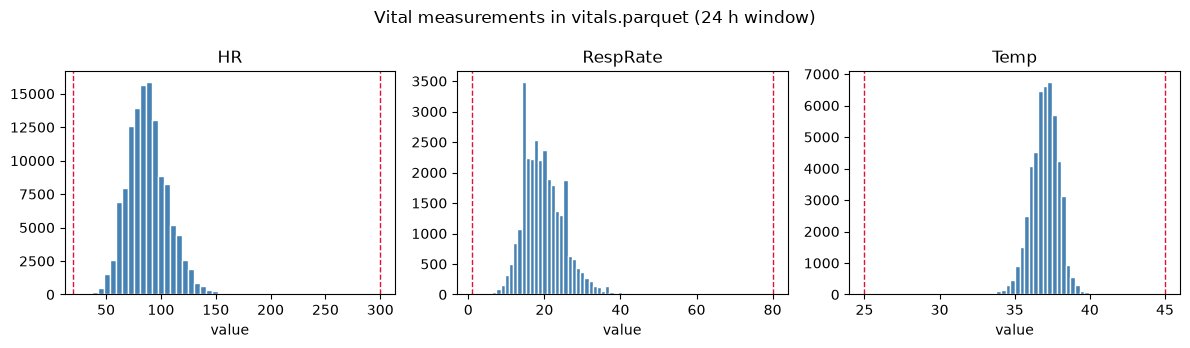

In [4]:
bounds = config["physiological_bounds"]
vitals_report = dq["vitals"]
summary_rows = []
for param in ("HR", "RespRate", "Temp"):
    block = vitals_report[param]
    summary_rows.append(
        {
            "parameter": param,
            "n_used": block["n_measurements_used"],
            "n_out_of_bounds": block["n_out_of_bounds"],
            "records_no_vital_24h": block["records_without_any_value_in_24h"],
            "p50": block["percentiles"]["p50"],
        }
    )
pd.DataFrame(summary_rows)

vitals_path = PROCESSED / "vitals.parquet"
if not vitals_path.exists():
    print("Skip histograms: run make data to create data/processed/vitals.parquet")
else:
    vitals = pd.read_parquet(vitals_path)
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
    for ax, param in zip(axes, ("HR", "RespRate", "Temp"), strict=True):
        values = vitals.loc[vitals["parameter"] == param, "value"]
        lo, hi = bounds[param]
        ax.hist(values, bins=50, color="steelblue", edgecolor="white")
        ax.axvline(lo, color="crimson", linestyle="--", linewidth=1)
        ax.axvline(hi, color="crimson", linestyle="--", linewidth=1)
        ax.set_title(param)
        ax.set_xlabel("value")
    fig.suptitle("Vital measurements in vitals.parquet (24 h window)")
    plt.tight_layout()
    plt.show()

## 4. Models on the held-out test set

Point metrics and bootstrap intervals are in `reports/metrics.json`. Curves were produced by `icu.evaluate` and saved under `reports/figures/`.


Served model: logistic_regression (Higher validation PR-AUC; if the difference is below 0.01, prefer logistic_regression for calibration, size, speed, and interpretability.)


,model,pr_auc,auroc,brier,sensitivity,alerts_per_100
0,logistic_regression (served),0.303,0.741,0.110,0.783,47.2
1,hist_gradient_boosting,0.350,0.776,0.105,0.855,48.2


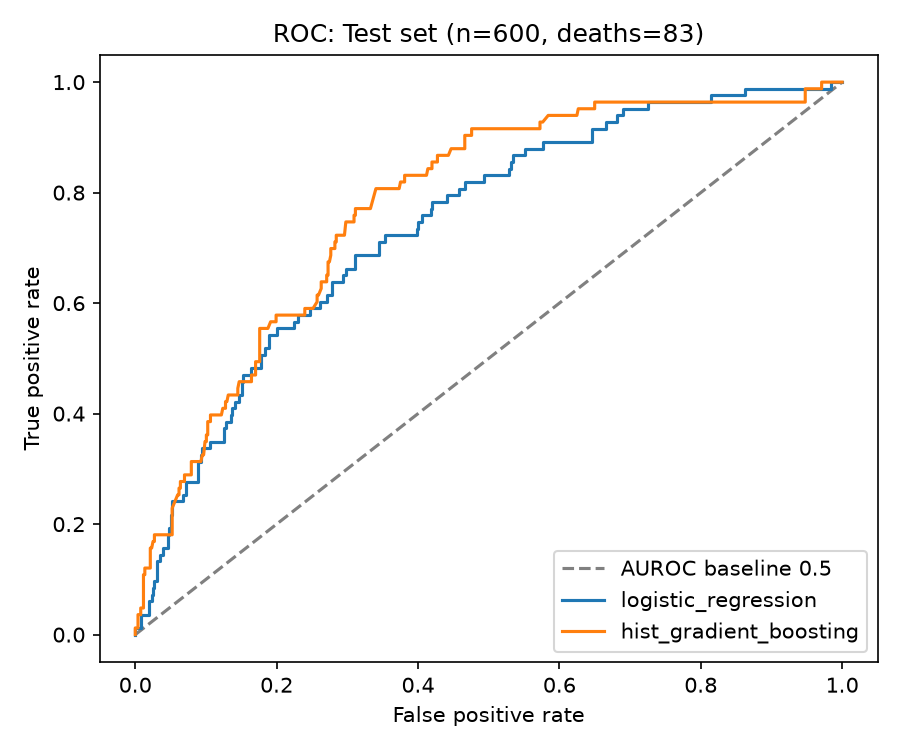

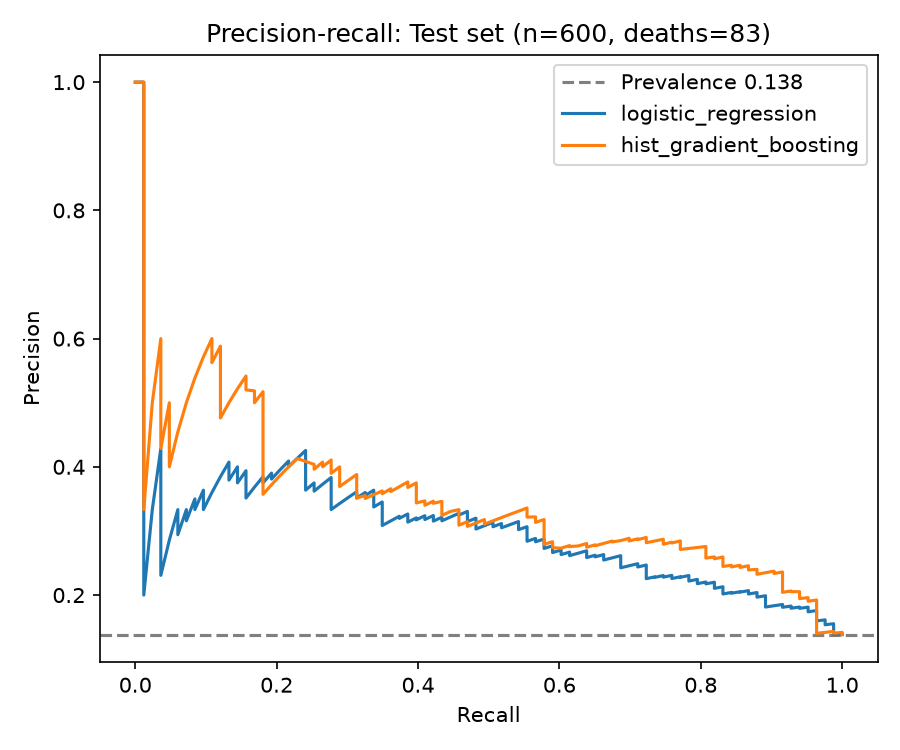

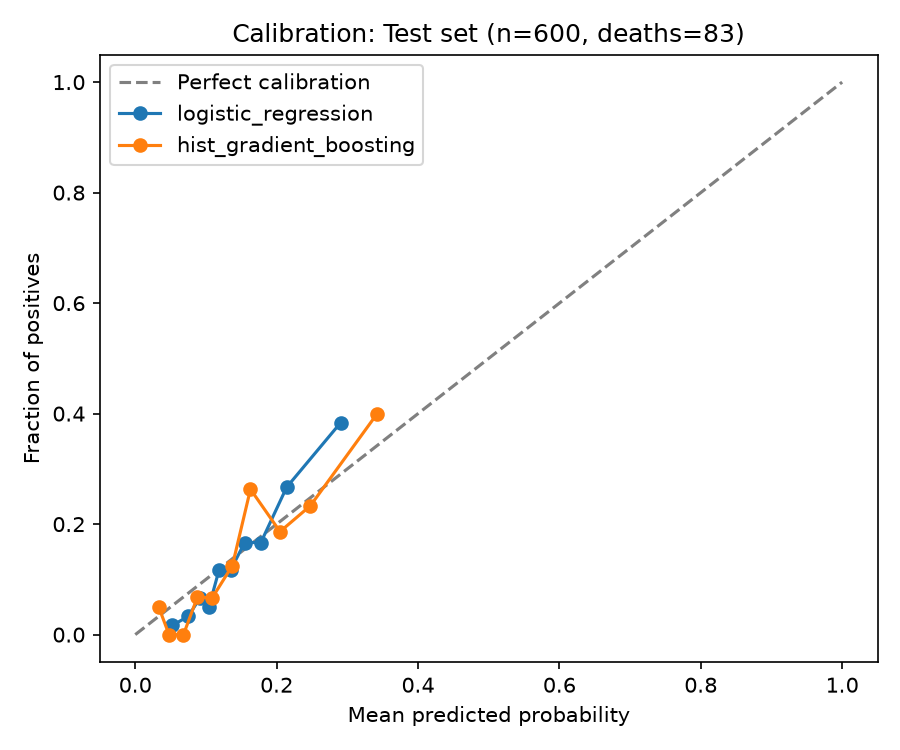

In [5]:
def metrics_row(model_key: str, label: str) -> dict[str, object]:
    block = metrics[model_key]["point_metrics"]
    return {
        "model": label,
        "pr_auc": round(block["pr_auc"], 3),
        "auroc": round(block["auroc"], 3),
        "brier": round(block["brier"], 3),
        "sensitivity": round(block["sensitivity"], 3),
        "alerts_per_100": round(block["alerts_per_100"], 1),
    }


metrics_table = pd.DataFrame(
    [
        metrics_row("logistic_regression", "logistic_regression (served)"),
        metrics_row("hist_gradient_boosting", "hist_gradient_boosting"),
    ]
)
print(f"Served model: {metrics['served_model']} ({metrics['served_model_rule']})")
display(metrics_table)

for name in ("roc.png", "pr.png", "calibration.png"):
    path = FIGURES / name
    display(Image(filename=str(path)))

## 5. ICUType subgroups (test set)

Per-type counts, observed death rates, and mean predicted probabilities are in `reports/subgroups.json` → `icu_type`.


In [6]:
sg = load_report("subgroups.json")["icu_type"]
rows = []
for icu_id in sorted(sg, key=int):
    block = sg[icu_id]
    lr = block["models"]["logistic_regression"]
    if lr.get("metrics") == "too few events":
        pr_auc_lr = "too few events"
    else:
        pr_auc_lr = round(lr["point_metrics"]["pr_auc"], 3)
    rows.append(
        {
            "ICUType": int(icu_id),
            "n": block["n"],
            "deaths": block["n_deaths"],
            "observed_death_rate": round(block["observed_death_rate"], 3),
            "mean_pred_prob_lr": round(lr["mean_predicted_probability"], 3),
            "pr_auc_lr": pr_auc_lr,
        }
    )
pd.DataFrame(rows)

,ICUType,n,deaths,observed_death_rate,mean_pred_prob_lr,pr_auc_lr
0,1,92,15,0.163,0.131,0.64
1,2,114,7,0.061,0.100,too few events
2,3,238,38,0.160,0.175,0.337
3,4,156,23,0.147,0.126,0.243


## 6. PSI monitoring (conceptual)

The API logs **bin indices** per continuous feature (`feature_bins` in each JSON log line), not raw vitals or ages. Training decile edges live in `models/1.0.1/metadata.json` → `training_reference.psi_bins`. `icu.monitor` compares recent bin counts to training proportions (alert above `monitoring.psi_alert`, default 0.25).

To simulate sensor bias locally:

```bash
uv run python scripts/send_requests.py --shift Temp=+1.5 --n 250
make monitor
```

Example log shape (synthetic, no patient values):

```json
{"path": "/predict", "feature_bins": {"temp_mean": 8, "temp_last": 9, "age": 3}}
```


In [7]:
meta_path = REPO_ROOT / "models" / "1.0.1" / "metadata.json"
with meta_path.open(encoding="utf-8") as handle:
    meta = _json.load(handle)
psi_features = sorted(meta["training_reference"]["psi_bins"])
print(f"PSI bin definitions for {len(psi_features)} features (metadata.json)")
print(", ".join(psi_features[:8]), "...")

PSI bin definitions for 10 features (metadata.json)
age, hr_count, hr_last, hr_mean, resp_rate_count, resp_rate_last, resp_rate_mean, temp_count ...


## 7. Live demo API (Cloud Run)

Optional smoke test against the deployed demo service. Uses `examples/valid.json` (no real patient identifiers beyond the example record id).


In [8]:
import urllib.error
import urllib.request

BASE_URL = "https://icu-api-demo-ir2das47na-nn.a.run.app"


def get_json(path: str) -> dict:
    url = BASE_URL.rstrip("/") + path
    with urllib.request.urlopen(url, timeout=30) as response:
        return _json.loads(response.read().decode("utf-8"))


def post_predict(body: dict) -> dict:
    url = BASE_URL.rstrip("/") + "/predict"
    data = _json.dumps(body).encode("utf-8")
    request = urllib.request.Request(
        url, data=data, headers={"Content-Type": "application/json"}, method="POST"
    )
    with urllib.request.urlopen(request, timeout=30) as response:
        return _json.loads(response.read().decode("utf-8"))


health = get_json("/health")
print("GET /health:", health)

with (REPO_ROOT / "examples" / "valid.json").open(encoding="utf-8") as handle:
    body = _json.load(handle)
try:
    predict = post_predict(body)
    dq_status = predict.get("data_quality", {})
    print("POST /predict data_quality:", dq_status)
    print("probability:", predict.get("probability"))
except urllib.error.URLError as exc:
    print("Cloud request failed (offline or service stopped):", exc)

GET /health: {'status': 'ok', 'model_version': '1.0.0'}
POST /predict data_quality: {'status': 'ok', 'missing_vitals': [], 'n_measurements_used': 5, 'n_excluded_after_cutoff': 0, 'n_out_of_range': 0}
probability: 0.0902
